대분류 중분류 통해서 "어떤 내용 위주의 외국인의 상담 주제"에 따른 분석 결과를 확인해야함. 수단은 안중요해서 다 결측치 처리해도 될듯 

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import matplotlib.font_manager as fm

# 한글 폰트 설정
mpl.rcParams['font.family'] = 'Malgun Gothic'
mpl.rcParams['axes.unicode_minus'] = False  # 마이너스 깨짐 방지



In [6]:
file_path = r'서울글로벌센터 접수유형 및 상담유형별(월) 상담실적.csv'

df = pd.read_csv(file_path, encoding='cp949')  # 또는 encoding='utf-8-sig'
df.head()

,년월,대분류,중분류,전화,방문,이메일,게시판,SNS,이동상담,문자,합계
0,202502,교육,교육기관,3,0,0,0,0,0,NaN,0
1,202502,교육,기타,5,1,0,0,0,0,NaN,0
2,202502,교육,보육시설,0,0,0,0,0,0,NaN,0
3,202502,교육,불편/개선건의,0,0,0,0,0,0,NaN,0
4,202502,교육,일반교육,10,13,0,0,0,0,NaN,0


In [7]:
# 컬럼 정보 + 결측치 + 타입
print("컬럼 정보 + 결측치 + 타입")
print(df.info())

# 각 컬럼별 결측치 개수
#print("각 컬럼별 결측치 개수")
#print(df.isnull().sum())

# 기초 통계 (숫자형만)
#print("기초 통계 (숫자형만)")
#print(df.describe())

컬럼 정보 + 결측치 + 타입
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8598 entries, 0 to 8597
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   년월      8598 non-null   int64  
 1   대분류     8598 non-null   object 
 2   중분류     8598 non-null   object 
 3   전화      8598 non-null   int64  
 4   방문      8598 non-null   int64  
 5   이메일     8598 non-null   int64  
 6   게시판     8598 non-null   int64  
 7   SNS     8598 non-null   int64  
 8   이동상담    8598 non-null   int64  
 9   문자      0 non-null      float64
 10  합계      8598 non-null   int64  
dtypes: float64(1), int64(8), object(2)
memory usage: 739.0+ KB
None


In [8]:
# 결측치 개수 확인
missing_values = df.isnull().sum()
print(missing_values)

년월         0
대분류        0
중분류        0
전화         0
방문         0
이메일        0
게시판        0
SNS        0
이동상담       0
문자      8598
합계         0
dtype: int64


In [9]:
# ✅ 1. 공백 → NaN
df = df.replace(r'^\s*$', pd.NA, regex=True)

# ✅ 2. '년월' → datetime 변환 (연도 기준만 사용)
df['년월'] = pd.to_datetime(df['년월'].astype(str).str[:4], format='%Y', errors='coerce')

# ✅ 3. 수단 열 (전화~이동상담) → 0으로 결측치 채우기
df.iloc[:, 3:9] = df.iloc[:, 3:9].fillna(0).astype(int)

# ✅ 4. 범주형 컬럼 → '미상'으로 채우기
cat_cols = df.select_dtypes(include='object').columns
df[cat_cols] = df[cat_cols].fillna('미상')

# ✅ 5. 상담건수 합계 열 생성
df['상담건수합계'] = df.iloc[:, 3:9].sum(axis=1)

# ✅ 6. 상담건수 0인 행 제거
df = df[df['상담건수합계'] > 0]

# ✅ 7. 대분류 + 중분류 기준 상담 건수 합산
grouped = df.groupby(['대분류', '중분류'])['상담건수합계'].sum().reset_index()

# ✅ 8. 상담건수 기준 상위 15개 주제 추출
grouped = grouped.sort_values(by='상담건수합계', ascending=False).head(15)



#수단 관련 plot show 인데 필요 없음 

df.hist(figsize=(16, 10), bins=20)
plt.suptitle("전체 수치형 변수 분포", fontsize=16)
plt.tight_layout()
plt.show()



필요 시 인덱스 설정 (예: 첫 열이 월 등 구분자일 경우)
df = df.set_index(df.columns[0])

array([[<Axes: title={'center': '년월'}>, <Axes: title={'center': '전화'}>,
        <Axes: title={'center': '방문'}>],
       [<Axes: title={'center': '이메일'}>, <Axes: title={'center': '게시판'}>,
        <Axes: title={'center': 'SNS'}>],
       [<Axes: title={'center': '이동상담'}>, <Axes: title={'center': '문자'}>,
        <Axes: title={'center': '합계'}>],
       [<Axes: title={'center': '상담건수합계'}>, <Axes: >, <Axes: >]],
      dtype=object)

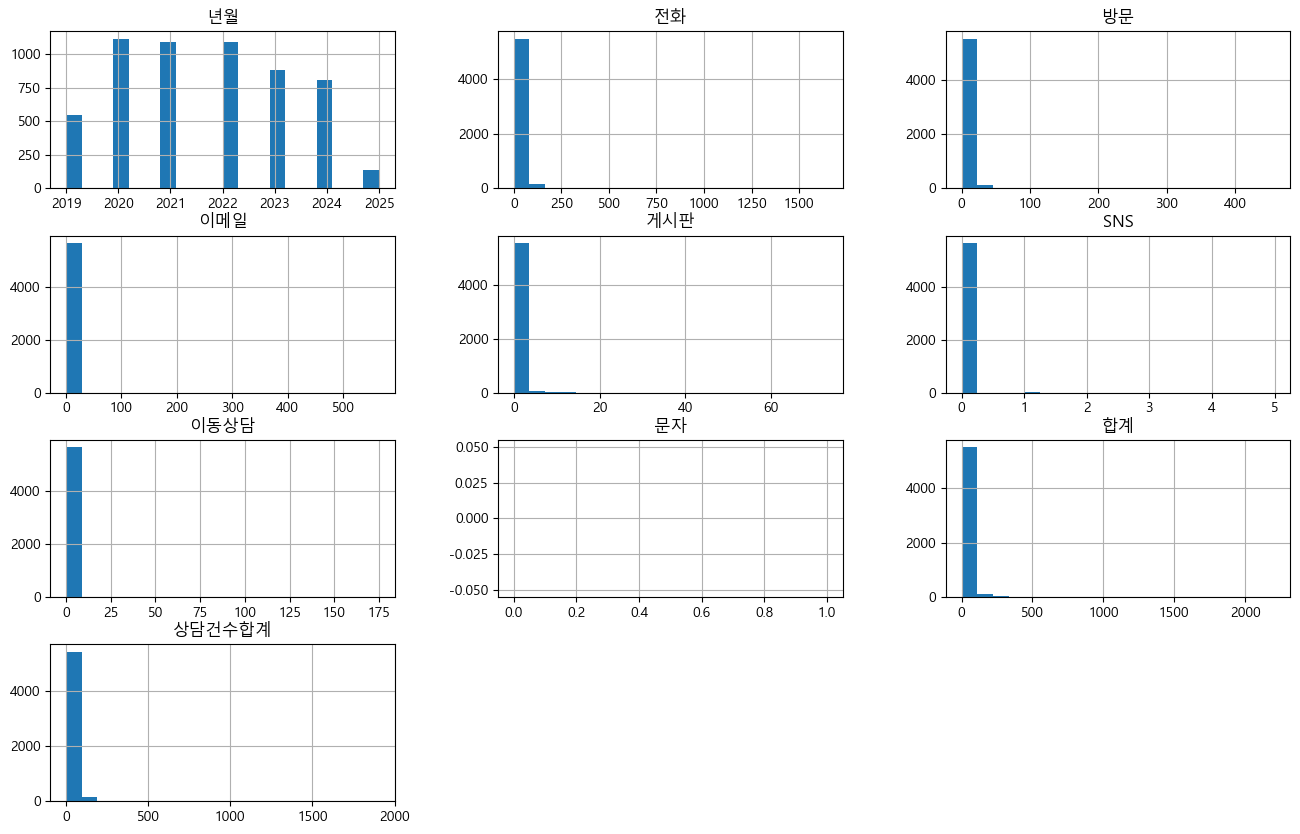

In [10]:
df.hist(figsize=(16, 10), bins=20)

#위의 한줄 코드와 이하 동문
for column in df.columns:
    if df[column].dtype in ['int64', 'float64']:
        sns.histplot(df[column], kde=True)
        plt.title(f"Distribution of {column}")
    else:
        sns.countplot(x=column, data=df)
        plt.title(f"{column}")
        plt.xticks(rotation=45)
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()


corr = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='Blues')
plt.title("수치형 변수 간 상관관계")
plt.show()


mlxtend plot은 결측치 이상으로 보류 
import matplotlib.pyplot as plt
from mlxtend.plotting import scatterplotmatrix
scatterplotmatrix(df.values)
plt.tight_layout()
plt.show()

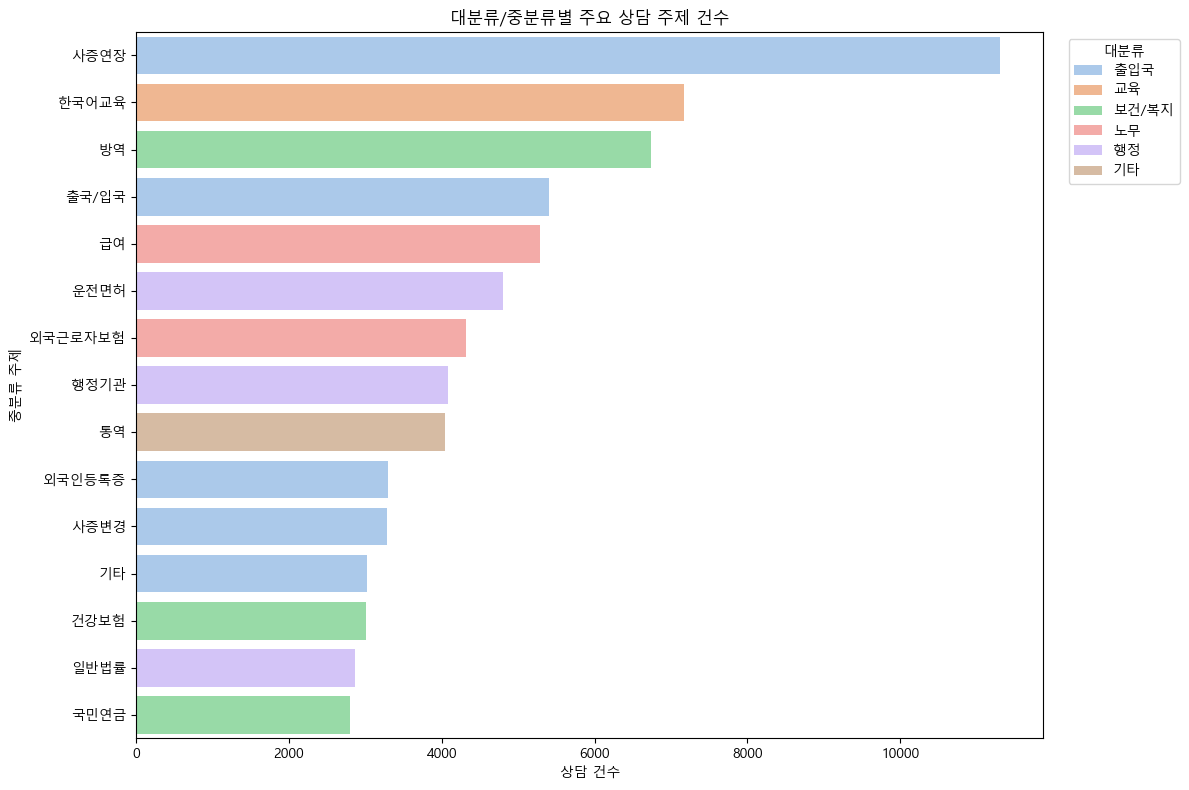

In [11]:
plt.figure(figsize=(12, 8))
sns.barplot(data=grouped, x='상담건수합계', y='중분류', hue='대분류', dodge=False, palette='pastel')
plt.title('대분류/중분류별 주요 상담 주제 건수')
plt.xlabel('상담 건수')
plt.ylabel('중분류 주제')
plt.legend(title='대분류', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()